# BESS Layout Optimization Tool

This notebook implements a layout optimization engine for Battery Energy Storage Systems (BESS).

## Objectives

- Define an arbitrary site using a polygon
- Place different types of equipment:
  - BESS containers (20 ft)
  - MVS / PCS containers (20 ft)
- Define:
  - Equipment footprint (2D)
  - Clearance distances (overlapping allowed)
- Configure maximum number of BESS per MVS
- Optimize layout to maximize battery count under constraints

## Key Assumptions

- Rectangular equipment footprints
- Clearance zones are allowed to overlap
- Equipment footprints cannot overlap
- Each BESS must be assigned to a MVS

In [1]:
# Install required packages (run once)

!pip install shapely matplotlib numpy


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: c:\Users\Alejandro\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


# Environment Check

This section ensures that all required libraries are correctly installed.

If this cell runs successfully, the environment is ready to execute the layout optimization workflow.

In [2]:
# Quick sanity check

from shapely.geometry import Polygon

poly = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

print("✅ Shapely working correctly:", poly.area == 100)

✅ Shapely working correctly: True


# Configuration

In this section, the main parameters of the layout problem are defined.

## Site Definition
- The site is defined as a polygon using a list of vertices (X, Y)

## Zone Types

Two types of zones are defined:

### 1. Non-buildable areas
- Equipment cannot be placed
- Can still be used for:
  - cable routing
  - access paths
  - fire lanes
- These areas block placement but do not reduce total usable layout space

### 2. Restricted areas
- Completely excluded from the site
- No usage allowed
- These areas are subtracted from the site geometry

## Equipment Types
- BESS containers
- MVS / PCS containers

Each equipment type includes:
- Footprint (width and height)
- Clearance (allowed to overlap with other clearance zones)

## System Constraints
- Maximum number of BESS units per MVS
- Grid resolution for placement candidates

This structure allows modeling realistic BESS layouts with engineering constraints.

In [3]:
# =========================================================
# ZONE DEFINITIONS
# =========================================================
# Trace the image measurements:
#
#   TOTAL SITE: 53.3 m wide × 90.4 m tall
#
#   Cable corridor (diagonal, non-buildable):
#     bottom: x = [15.4, 21.9]  →  6.5 m wide
#     top:    x = [31.9, 47.7]  →  15.8 m wide
#
#   Lower-right triangle: base 31.4 m, height ~16 m  (244 m²)
#
#   Top-left indent: 8 m step at the upper-left corner
# =========================================================

# Cable protection corridor — diagonal, widens top to bottom
cable_corridor = [
    (15.4,  0),
    (21.9,  0),
    (47.7,  90.4),
    (31.9,  90.4)
]

# Area outside scope (solar panels) — right of cable corridor above y = 16 m
# Defined as RESTRICTED: completely removed from site geometry
out_of_scope = [
    (21.9,  16),
    (53.3,  16),
    (53.3,  90.4),
    (47.7,  90.4)
]


In [4]:
# =========================================================
# KEY INPUTS — edit here before running
# =========================================================

# --- Equipment footprint dimensions (metres) ---
# Sungrow PowerTitan 20-ft container
BESS_WIDTH  = 6.06
BESS_HEIGHT = 2.44

MVS_WIDTH   = 6.06
MVS_HEIGHT  = 2.44

# --- Clearance distances (metres) — asymmetric per side ---
#   front = facing the access aisle (+ Y direction)
#   back  = rear of the container   (- Y direction)
#   left  = left side               (- X direction)
#   right = right side              (+ X direction)
#
# Clearances are shown in the plot but NOT hard exclusions:
# clearance zones CAN overlap with each other — only footprints cannot.
# Footprints also cannot enter another container's clearance zone.

BESS_CLEARANCE = {
    "front": 2.0,
    "back":  1.0,
    "left":  1.0,
    "right": 1.0,
}

MVS_CLEARANCE = {
    "front": 3.0,
    "back":  1.5,
    "left":  1.5,
    "right": 1.5,
}

# --- Global engineering rules (apply to all modes) ---
MAX_BESS_PER_MVS = 4         # capacity per transformer
MAX_CABLE_LENGTH = 25        # hard cap on any single BESS↔MVS cable run (m)

# Radius (m) used when SCORING candidate MVS positions: only grid points
# within this distance count as "reachable" neighbours, so an MVS that would
# land in a saturated zone scores nothing and is skipped.
# Set to 0 to disable the neighbourhood filter entirely.
MVS_SCORING_RADIUS = 25

# Additional minimum centre-to-centre distance between MVS units (m).
# Set to 0 to rely only on the clearance geometry (recommended).
MIN_MVS_SPACING  = 0

# --- Layout resolution ---
# Use a step close to the BESS width for better row alignment.
GRID_RESOLUTION = 2.0

SETBACK = 0


In [5]:
# =========================================================
# CONFIGURATION  (references KEY INPUTS above)
# =========================================================

CONFIG = {

    # ---------------------------
    # SITE DEFINITION
    # ---------------------------
    # Vertices traced from the image (clockwise from bottom-left):
    #
    #   (0, 0)        bottom-left
    #   (53.3, 0)     bottom-right  (15.4 + 6.5 + 31.4 = 53.3 m)
    #   (53.3, 16)    right side of lower triangle (height ~16 m)
    #   (21.9, 16)    triangle apex — site cuts back left here
    #   (47.7, 90.4)  top-right (cable corridor right edge at top)
    #   (8,    90.4)  top-left with 8 m indent
    #   (0,    90.4)  top-left corner
    #
    # The cable corridor (non-buildable) runs diagonally inside this polygon.
    # The solar-panel area above y=16 and right of the corridor is removed via
    # the restricted zone.
    "site_vertices": [
        (0,     0),
        (53.3,  0),
        (53.3,  16),    # top-right of lower triangle
        (21.9,  16),    # triangle apex
        (47.7,  90.4),  # follows cable corridor right edge to top
        (8,     90.4),  # top-left with 8 m indent
        (0,     90.4),  # top-left corner
    ],

    "setback": SETBACK,

    # ---------------------------
    # ZONES
    # ---------------------------
    "zones": {
        "non_buildable": [cable_corridor],
        "restricted":    [out_of_scope]
    },

    # ---------------------------
    # EQUIPMENT TYPES
    # ---------------------------
    "equipment": {
        "BESS": {
            "width":     BESS_WIDTH,
            "height":    BESS_HEIGHT,
            "clearance": BESS_CLEARANCE
        },
        "MVS": {
            "width":     MVS_WIDTH,
            "height":    MVS_HEIGHT,
            "clearance": MVS_CLEARANCE
        }
    },

    # ---------------------------
    # GLOBAL ENGINEERING RULES
    # ---------------------------
    "max_bess_per_mvs":   MAX_BESS_PER_MVS,
    "max_cable_length":   MAX_CABLE_LENGTH,
    "mvs_scoring_radius": MVS_SCORING_RADIUS,
    "min_mvs_spacing":    MIN_MVS_SPACING,
    "grid_resolution":    GRID_RESOLUTION,
}


# Geometry and Site Preparation

This section defines how the site geometry is prepared before placing equipment.

## Key Steps

1. Create the base site polygon from vertices
2. Apply setback (inward buffer)
3. Subtract restricted areas from the site
4. Keep non-buildable zones as internal constraints
5. Generate candidate placement positions using a grid

## Important Behavior

- Restricted areas → removed from the usable site
- Non-buildable areas → remain inside the site but block placement
- Clearance between equipment is allowed to overlap

The combination of these rules allows realistic modeling of:
- access roads
- fire lanes
- no-build zones
- environmental restrictions

In [6]:
from shapely.geometry import Polygon
import numpy as np

def create_site(vertices):
    site = Polygon(vertices)

    if not site.is_valid:
        raise ValueError("Invalid polygon: check vertex order")

    return site


def prepare_site(site, config):

    # 1. Apply setback
    usable_site = site.buffer(-config["setback"])

    # 2. Remove restricted zones
    for zone in config["zones"]["restricted"]:
        zone_poly = Polygon(zone)
        usable_site = usable_site.difference(zone_poly)

    # 3. Keep non-buildable zones (for placement checks later)
    non_buildable_polys = [
        Polygon(z) for z in config["zones"]["non_buildable"]
    ]

    return usable_site, non_buildable_polys


def create_candidate_grid(site, resolution):
    minx, miny, maxx, maxy = site.bounds

    xs = np.arange(minx, maxx, resolution)
    ys = np.arange(miny, maxy, resolution)

    return [(x, y) for x in xs for y in ys]

# Equipment Placement Logic

This section defines how equipment is placed within the site.

## Placement Rules

### 1. Footprint constraints
- Equipment footprints must:
  - Be fully inside the usable site
  - Not intersect with other equipment
  - Not overlap with non-buildable zones

### 2. Clearance concept
- Each equipment has a clearance distance
- Clearance areas:
  - Can overlap with other clearances
  - Represent safety, fire, or O&M spacing
- Clearance is NOT treated as a hard exclusion

### 3. Placement Strategy

The placement is done sequentially:

1. Place MVS units first
2. Assign BESS units to MVS based on proximity
3. Ensure each MVS does not exceed maximum BESS capacity

## Objective

Maximize the number of BESS units while ensuring:
- Proper assignment to MVS
- Valid spatial layout


In [7]:
from shapely.geometry import box

def create_equipment_polygon(x, y, width, height):
    return box(x, y, x + width, y + height)


def create_clearance_polygon(footprint, clearance):
    """
    Build an asymmetric clearance rectangle around a footprint.
    clearance dict keys: front (+Y), back (-Y), left (-X), right (+X).
    """
    minx, miny, maxx, maxy = footprint.bounds
    return box(
        minx - clearance["left"],
        miny - clearance["back"],
        maxx + clearance["right"],
        maxy + clearance["front"],
    )


def is_valid_placement(candidate_fp, candidate_cl, site, non_buildable, placed):
    """
    Placement rules:
      - Footprint must be fully inside the usable site
      - Footprint must not intersect non-buildable zones
      - Footprint must not enter any existing clearance zone
      - New clearance zone must not overlap any existing footprint
      (clearance zones CAN overlap each other — that is allowed)
    """
    if not site.contains(candidate_fp):
        return False

    for zone in non_buildable:
        if candidate_fp.intersects(zone):
            return False

    for obj in placed:
        # New footprint inside existing clearance zone → blocked
        if candidate_fp.intersects(obj["clearance_zone"]):
            return False
        # New clearance zone overlaps existing footprint → blocked
        if candidate_cl.intersects(obj["footprint"]):
            return False

    return True


# MVS and BESS Placement Strategy

This section defines the logic used to allocate equipment across the site.

## MVS Placement

- MVS units are placed first
- They act as anchors for BESS allocation
- Placement is based on valid grid positions

## BESS Placement

- BESS units are placed after MVS
- Each BESS unit is assigned to the nearest MVS
- Assignment is constrained by:
  - Maximum BESS per MVS

## Optimization Philosophy

- Prioritize filling MVS to maximum capacity
- Use proximity (distance) as assignment metric
- Avoid scattered layouts where possible

This approach approximates real BESS design methodology where:
- Power blocks are centered around PCS/MVS
- Batteries are clustered around conversion units

In [8]:
# ════════════════════════════════════════════════════════════════════════
# CLUSTER PLACEMENT — three-mode (conservative / aggressive / ultra)
# ════════════════════════════════════════════════════════════════════════
#
# Shared engine, mode-specific parameter profile.  Modes differ in six knobs:
#
#   - alignment_weight    : penalty for off-axis BESS (rows/columns)
#   - mvs_y_band_bonus    : score discount for MVS sharing a Y-band
#   - require_adjacency   : Phase 1 BESS must touch an existing cluster member
#   - do_stragglers       : Phase 2 fills leftover slots within cable cap
#   - cable_cap_override  : None → use CONFIG max_cable; value → override
#                           (set to 0 to disable cable cap during placement)
#   - hungarian_cap_override : None → use CONFIG max_cable; value → override
#                           (set to 0 to allow ANY-distance assignments)
#
# Why the rewiring step makes relaxed adjacency safe (aggressive mode):
#   The Hungarian rewiring uses cost = ∞ for any BESS↔MVS pair exceeding
#   max_cable_length, so the matching is forbidden from producing a long
#   cable — stranding is geometrically impossible.  Ultra-aggressive lifts
#   this and accepts that some cables may exceed the 25 m operating limit
#   in exchange for raw footprint saturation.
# ════════════════════════════════════════════════════════════════════════


def _prune_avail(avail, blocker_fp, blocker_cl, bess_eq):
    """Drop grid positions whose BESS footprint/clearance conflicts with blocker."""
    bess_cl_dict = bess_eq["clearance"]
    w, h = bess_eq["width"], bess_eq["height"]
    out = []
    for (gx, gy) in avail:
        b_fp = create_equipment_polygon(gx, gy, w, h)
        b_cl = create_clearance_polygon(b_fp, bess_cl_dict)
        if b_fp.intersects(blocker_cl) or blocker_fp.intersects(b_cl):
            continue
        out.append((gx, gy))
    return out


def _score_mvs(cx, cy, avail_arr, scoring_r, max_ratio):
    """Sum of distances to the max_ratio nearest reachable grid points."""
    dists = np.hypot(avail_arr[:, 0] - cx, avail_arr[:, 1] - cy)
    reachable = dists[dists <= scoring_r] if scoring_r > 0 else dists
    top_k = np.sort(reachable)[1 : max_ratio + 1]
    return float(top_k.sum()) if top_k.size > 0 else float("inf")


def _grow_cluster(mvs_obj, avail, site, non_buildable, placed, bess_eq,
                  max_ratio, max_cable, alignment_weight, require_adjacency):
    """
    Cluster growth around a placed MVS.
      - hard cable cap: d_mvs ≤ max_cable (skipped when max_cable ≤ 0)
      - if require_adjacency: new clearance must overlap an existing member's
      - score = d_mvs + 0.5 * d_cluster (+ alignment_weight if off-axis)
    """
    bess_cl_dict = bess_eq["clearance"]
    w, h = bess_eq["width"], bess_eq["height"]
    mx_c, my_c = mvs_obj["footprint"].centroid.x, mvs_obj["footprint"].centroid.y
    members = [mvs_obj]
    added = []

    for _ in range(max_ratio):
        best = None
        best_score = float("inf")

        for (gx, gy) in avail:
            b_fp = create_equipment_polygon(gx, gy, w, h)
            b_cl = create_clearance_polygon(b_fp, bess_cl_dict)
            if not is_valid_placement(b_fp, b_cl, site, non_buildable, placed):
                continue
            bx, by = b_fp.centroid.x, b_fp.centroid.y
            d_mvs = np.hypot(bx - mx_c, by - my_c)
            if max_cable > 0 and d_mvs > max_cable:
                continue
            if require_adjacency and not any(
                b_cl.intersects(c["clearance_zone"]) for c in members
            ):
                continue

            d_cluster = min(
                np.hypot(c["footprint"].centroid.x - bx,
                         c["footprint"].centroid.y - by)
                for c in members
            )
            score = d_mvs + 0.5 * d_cluster

            if alignment_weight > 0:
                tol = 0.5
                aligned = any(
                    abs(c["footprint"].centroid.x - bx) < tol or
                    abs(c["footprint"].centroid.y - by) < tol
                    for c in members
                )
                if not aligned:
                    score += alignment_weight

            if score < best_score:
                best_score = score
                best = (b_fp, b_cl)

        if best is None:
            break

        b_fp, b_cl = best
        bess_obj = {
            "type":           "BESS",
            "footprint":      b_fp,
            "clearance_zone": b_cl,
            "mvs":            mvs_obj,
        }
        placed.append(bess_obj)
        mvs_obj["assigned_bess"].append(bess_obj)
        members.append(bess_obj)
        added.append(bess_obj)
        avail = _prune_avail(avail, b_fp, b_cl, bess_eq)

    return added, avail


def _stragglers_pass(avail, site, non_buildable, placed, mvs_list, bess_list,
                     bess_eq, max_ratio, max_cable):
    """
    Aggressive Phase 2: place BESS at any remaining valid slot whose nearest
    MVS-with-capacity is within max_cable (or anywhere if max_cable ≤ 0).
    """
    bess_cl_dict = bess_eq["clearance"]
    w, h = bess_eq["width"], bess_eq["height"]
    unlimited = max_cable <= 0

    while True:
        candidates = []
        for (gx, gy) in avail:
            b_fp = create_equipment_polygon(gx, gy, w, h)
            b_cl = create_clearance_polygon(b_fp, bess_cl_dict)
            if not is_valid_placement(b_fp, b_cl, site, non_buildable, placed):
                continue
            bx, by = b_fp.centroid.x, b_fp.centroid.y
            best_mvs = None
            best_d = float("inf")
            for m in mvs_list:
                if len(m["assigned_bess"]) >= max_ratio:
                    continue
                mx, my = m["footprint"].centroid.x, m["footprint"].centroid.y
                d = np.hypot(bx - mx, by - my)
                if (unlimited or d <= max_cable) and d < best_d:
                    best_d = d
                    best_mvs = m
            if best_mvs is None:
                continue
            candidates.append((best_d, b_fp, b_cl, best_mvs))

        if not candidates:
            break

        candidates.sort(key=lambda c: c[0])
        _, b_fp, b_cl, mvs = candidates[0]
        bess_obj = {
            "type":           "BESS",
            "footprint":      b_fp,
            "clearance_zone": b_cl,
            "mvs":            mvs,
        }
        placed.append(bess_obj)
        bess_list.append(bess_obj)
        mvs["assigned_bess"].append(bess_obj)
        avail = _prune_avail(avail, b_fp, b_cl, bess_eq)

    return avail


def _optimal_reassign(mvs_list, bess_list, max_cable, max_ratio):
    """
    Phase 3: global min-cost BESS→MVS rewiring.  Hungarian when scipy is
    available, greedy fallback otherwise.  Pairs with distance > max_cable are
    forbidden (cost = ∞), unless max_cable ≤ 0 in which case ANY distance is
    allowed (used by ultra-aggressive to route over the 25 m operating limit).
    """
    if not mvs_list or not bess_list:
        return mvs_list, bess_list

    n_b = len(bess_list)
    n_m = len(mvs_list)
    n_slots = n_m * max_ratio

    bp = np.array([[b["footprint"].centroid.x, b["footprint"].centroid.y] for b in bess_list])
    mp = np.array([[m["footprint"].centroid.x, m["footprint"].centroid.y] for m in mvs_list])

    INF = 1e9
    cost = np.full((n_b, n_slots), INF)
    for j in range(n_m):
        d = np.hypot(bp[:, 0] - mp[j, 0], bp[:, 1] - mp[j, 1])
        feasible = np.ones_like(d, dtype=bool) if max_cable <= 0 else d <= max_cable
        for k in range(max_ratio):
            cost[feasible, j * max_ratio + k] = d[feasible]

    try:
        from scipy.optimize import linear_sum_assignment
        row_ind, col_ind = linear_sum_assignment(cost)
    except ImportError:
        order = sorted(range(n_b), key=lambda i: cost[i].min())
        used = set()
        row_ind, col_ind = [], []
        for i in order:
            for j in np.argsort(cost[i]):
                j = int(j)
                if j in used or cost[i, j] >= INF:
                    continue
                row_ind.append(i)
                col_ind.append(j)
                used.add(j)
                break
        row_ind = np.array(row_ind)
        col_ind = np.array(col_ind)

    for m in mvs_list:
        m["assigned_bess"] = []
    new_bess = []
    for i, j in zip(row_ind, col_ind):
        if cost[i, j] >= INF:
            continue
        m = mvs_list[j // max_ratio]
        b = bess_list[i]
        b["mvs"] = m
        m["assigned_bess"].append(b)
        new_bess.append(b)

    mvs_list = [m for m in mvs_list if m["assigned_bess"]]
    return mvs_list, new_bess


# ─── Mode profiles ───────────────────────────────────────────────────

_MODE_PROFILES = {
    "conservative": {
        # Goal: visual symmetry, clean rectangular blocks, uniform clusters.
        "alignment_weight":      8.0,
        "mvs_y_band_bonus":      0.85,
        "require_adjacency":     True,
        "do_stragglers":         False,
        "cable_cap_override":    None,   # honour CONFIG max_cable_length
        "hungarian_cap_override": None,
    },
    "aggressive": {
        # Goal: max BESS count under the 25 m cable cap.
        "alignment_weight":      0.0,
        "mvs_y_band_bonus":      1.0,
        "require_adjacency":     False,
        "do_stragglers":         True,
        "cable_cap_override":    None,
        "hungarian_cap_override": None,
    },
    "ultra_aggressive": {
        # Goal: absolute footprint saturation.  Cable cap LIFTED in both
        # placement and Hungarian rewiring — accepts longer cable runs in
        # exchange for raw BESS count.  MVS count scales naturally with the
        # number of BESS the site can absorb.
        "alignment_weight":      0.0,
        "mvs_y_band_bonus":      1.0,
        "require_adjacency":     False,
        "do_stragglers":         True,
        "cable_cap_override":    0,      # 0 = unlimited during placement
        "hungarian_cap_override": 0,     # 0 = no INF penalty in matching
    },
}


def place_clusters(site, non_buildable, grid, config, mode="aggressive"):
    """Three-mode multi-pass placement.  See module docstring at top of cell."""
    if mode not in _MODE_PROFILES:
        raise ValueError(f"Unknown mode {mode!r}; expected one of {list(_MODE_PROFILES)}")
    profile = _MODE_PROFILES[mode]

    mvs_eq      = config["equipment"]["MVS"]
    bess_eq     = config["equipment"]["BESS"]
    mvs_cl_dict = mvs_eq["clearance"]
    min_spacing = config.get("min_mvs_spacing", 0)
    max_ratio   = config["max_bess_per_mvs"]
    scoring_r   = config.get("mvs_scoring_radius", 0)

    base_cable     = config.get("max_cable_length", 25)
    eff_cable      = profile["cable_cap_override"] if profile["cable_cap_override"] is not None else base_cable
    eff_hungarian  = profile["hungarian_cap_override"] if profile["hungarian_cap_override"] is not None else base_cable

    cx_off = bess_eq["width"]  / 2
    cy_off = bess_eq["height"] / 2

    placed    = []
    mvs_list  = []
    bess_list = []
    avail     = list(grid)

    # ── Phase 1: seed MVS + grow cluster, repeat ─────────────────────────
    while True:
        if len(avail) < max_ratio + 1:
            break

        avail_arr = np.array([[x + cx_off, y + cy_off] for x, y in avail])

        best = None
        best_score = float("inf")

        for (mx, my) in avail:
            mvs_fp = create_equipment_polygon(mx, my, mvs_eq["width"], mvs_eq["height"])
            mvs_cl = create_clearance_polygon(mvs_fp, mvs_cl_dict)
            if not is_valid_placement(mvs_fp, mvs_cl, site, non_buildable, placed):
                continue

            cx, cy = mvs_fp.centroid.x, mvs_fp.centroid.y
            if min_spacing > 0 and any(
                (cx - m["footprint"].centroid.x) ** 2 + (cy - m["footprint"].centroid.y) ** 2
                < min_spacing ** 2
                for m in mvs_list
            ):
                continue

            score = _score_mvs(cx, cy, avail_arr, scoring_r, max_ratio)

            if profile["mvs_y_band_bonus"] < 1.0 and mvs_list:
                tol = 1.5
                if any(abs(cy - m["footprint"].centroid.y) < tol for m in mvs_list):
                    score *= profile["mvs_y_band_bonus"]

            if score < best_score:
                best_score = score
                best = (mvs_fp, mvs_cl)

        if best is None:
            break

        mvs_fp, mvs_cl = best
        mvs_obj = {
            "type":           "MVS",
            "footprint":      mvs_fp,
            "clearance_zone": mvs_cl,
            "assigned_bess":  [],
        }
        placed.append(mvs_obj)
        mvs_list.append(mvs_obj)
        avail = _prune_avail(avail, mvs_fp, mvs_cl, bess_eq)

        added, avail = _grow_cluster(
            mvs_obj, avail, site, non_buildable, placed, bess_eq,
            max_ratio, eff_cable,
            profile["alignment_weight"],
            profile["require_adjacency"],
        )
        bess_list.extend(added)

        if not mvs_obj["assigned_bess"]:
            placed.remove(mvs_obj)
            mvs_list.remove(mvs_obj)

    # ── Phase 2: stragglers ──────────────────────────────────────────────
    if profile["do_stragglers"] and mvs_list:
        avail = _stragglers_pass(
            avail, site, non_buildable, placed, mvs_list, bess_list,
            bess_eq, max_ratio, eff_cable,
        )

    # ── Phase 3: optimal global rewiring ─────────────────────────────────
    if mvs_list:
        mvs_list, bess_list = _optimal_reassign(mvs_list, bess_list, eff_hungarian, max_ratio)

    return mvs_list, bess_list


In [9]:
def total_cable_length(mvs_list):
    """Sum of centroid-to-centroid distances for all BESS–MVS pairs (metres)."""
    total = 0.0
    for mvs in mvs_list:
        mx, my = mvs["footprint"].centroid.x, mvs["footprint"].centroid.y
        for b in mvs["assigned_bess"]:
            bx, by = b["footprint"].centroid.x, b["footprint"].centroid.y
            total += np.hypot(bx - mx, by - my)
    return total


# Optimization Execution

This section combines all previous components into a single workflow.

## Process Overview

1. Create base site geometry
2. Apply setback and zone constraints
3. Generate candidate grid points
4. Place MVS units across the site
5. Allocate BESS units to MVS based on proximity and capacity
6. Compute final metrics

## Output

- Total number of MVS units
- Total number of BESS units
- Average BESS per MVS ratio

This step produces the final layout data used for visualization.


In [10]:
def _compute_metrics(site, non_buildable, mvs_list, bess_list, max_ratio):
    """Derived layout metrics: counts, cable totals, area saturation."""
    n_mvs  = len(mvs_list)
    n_bess = len(bess_list)
    cable  = total_cable_length(mvs_list)
    avg    = cable / n_bess if n_bess else 0.0
    full   = sum(1 for m in mvs_list if len(m["assigned_bess"]) == max_ratio)

    # Longest single cable run — exposes ultra-aggressive's cable-cap trade-off.
    max_cable = 0.0
    for m in mvs_list:
        mx, my = m["footprint"].centroid.x, m["footprint"].centroid.y
        for b in m["assigned_bess"]:
            bx, by = b["footprint"].centroid.x, b["footprint"].centroid.y
            d = float(np.hypot(bx - mx, by - my))
            if d > max_cable:
                max_cable = d

    # Buildable area = usable site minus the parts of non-buildable zones that
    # actually overlap the site (cable corridor, etc.).
    buildable = site.area
    for nb in non_buildable:
        buildable -= nb.intersection(site).area

    eq_area = (
        sum(m["footprint"].area for m in mvs_list)
        + sum(b["footprint"].area for b in bess_list)
    )
    area_sat = (100 * eq_area / buildable) if buildable > 0 else 0.0
    cap_sat  = (100 * n_bess / (n_mvs * max_ratio)) if n_mvs else 0.0

    return {
        "mvs_count":               n_mvs,
        "bess_count":              n_bess,
        "max_cap":                 max_ratio,
        "full_mvs":                full,
        "total_cable":             cable,
        "avg_cable":               avg,
        "max_cable_used":          max_cable,
        "buildable_area":          buildable,
        "equipment_area":          eq_area,
        "area_saturation_pct":     area_sat,
        "capacity_saturation_pct": cap_sat,
    }


def run_optimization(config, mode="aggressive", verbose=True):
    """Run the full pipeline for one mode and return a results bundle."""
    site_raw = create_site(config["site_vertices"])
    site, non_buildable = prepare_site(site_raw, config)
    grid = create_candidate_grid(site, config["grid_resolution"])

    mvs_list, bess_list = place_clusters(site, non_buildable, grid, config, mode=mode)
    metrics = _compute_metrics(site, non_buildable, mvs_list, bess_list,
                               config["max_bess_per_mvs"])

    if verbose:
        print(f"\n----- {mode.upper()} -----")
        print(f"MVS units placed   : {metrics['mvs_count']}")
        print(f"BESS units placed  : {metrics['bess_count']}")
        print(f"Fully sat. MVS     : {metrics['full_mvs']} / {metrics['mvs_count']}")
        print(f"Total cable        : {metrics['total_cable']:.1f} m")
        print(f"Avg cable / BESS   : {metrics['avg_cable']:.1f} m")
        print(f"Max cable run      : {metrics['max_cable_used']:.1f} m")
        print(f"Area saturation    : {metrics['area_saturation_pct']:.1f}%")
        print(f"Capacity saturation: {metrics['capacity_saturation_pct']:.1f}%")

    return {
        "mode":          mode,
        "site":          site,
        "non_buildable": non_buildable,
        "mvs_list":      mvs_list,
        "bess_list":     bess_list,
        "metrics":       metrics,
    }


# Visualization

This section generates a 2D layout representation of the optimized site.

## Color Legend

- Black → Site boundary
- Yellow → Non-buildable zones
- Red → MVS containers
- Blue → BESS containers

## Purpose

The visualization allows:
- Quick validation of layout feasibility
- Identification of unused areas
- Communication with stakeholders (engineering / commercial)

This output is critical for early-stage design and proposal development.

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Tall site (≈53×90 m) → portrait aspect by default.
DEFAULT_STANDALONE_FIGSIZE = (10, 14)
DEFAULT_PANEL_FIGSIZE      = (7, 10)   # used per panel in side-by-side


def plot_layout(site, non_buildable, mvs_list, bess_list, config,
                ax=None, title=None, figsize=None):
    """Render a single layout.  Pass ax to compose into a subplot grid."""
    bess_cl_cfg = config["equipment"]["BESS"]["clearance"]
    mvs_cl_cfg  = config["equipment"]["MVS"]["clearance"]

    n   = len(mvs_list)
    tab = plt.cm.tab10.colors if n <= 10 else plt.cm.tab20.colors
    colors = [tab[i % len(tab)] for i in range(n)]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize or DEFAULT_STANDALONE_FIGSIZE)

    if not site.is_empty:
        x, y = site.exterior.xy
        ax.plot(x, y, color="black", linewidth=2)

    for zone in non_buildable:
        if not zone.is_empty:
            x, y = zone.exterior.xy
            ax.fill(x, y, color="gold", alpha=0.45)
            ax.plot(x, y, color="goldenrod", linewidth=1)

    legend_handles = [mpatches.Patch(color="gold", alpha=0.45, label="Non-buildable zone")]

    for i, (mvs, col) in enumerate(zip(mvs_list, colors)):
        r, g, b = col[:3]
        dark    = (r * 0.50, g * 0.50, b * 0.50)

        mvs_cl_poly = create_clearance_polygon(mvs["footprint"], mvs_cl_cfg)
        x, y = mvs_cl_poly.exterior.xy
        ax.fill(x, y, color=col, alpha=0.12, zorder=1)
        ax.plot(x, y, color=col, linewidth=0.8, linestyle="--", alpha=0.6, zorder=1)

        for bess in mvs["assigned_bess"]:
            ax.plot(
                [bess["footprint"].centroid.x, mvs["footprint"].centroid.x],
                [bess["footprint"].centroid.y, mvs["footprint"].centroid.y],
                color=col, linewidth=1.2, alpha=0.85, zorder=2,
            )
            bess_cl_poly = create_clearance_polygon(bess["footprint"], bess_cl_cfg)
            x, y = bess_cl_poly.exterior.xy
            ax.fill(x, y, color=col, alpha=0.10, zorder=1)
            ax.plot(x, y, color=col, linewidth=0.5, linestyle="--", alpha=0.4, zorder=1)

            x, y = bess["footprint"].exterior.xy
            ax.fill(x, y, color=col, alpha=0.75, zorder=3)
            ax.plot(x, y, color="black", linewidth=0.5, zorder=3)

        x, y = mvs["footprint"].exterior.xy
        ax.fill(x, y, color=dark, alpha=0.95, zorder=4)
        ax.plot(x, y, color="black", linewidth=0.8, zorder=4)
        # Larger label in standalone view since the figure is bigger.
        label_fs = 8 if standalone else 6
        ax.text(
            mvs["footprint"].centroid.x, mvs["footprint"].centroid.y,
            f"M{i + 1}", ha="center", va="center",
            fontsize=label_fs, color="white", fontweight="bold", zorder=5,
        )

        legend_handles.append(mpatches.Patch(
            color=col, alpha=0.80,
            label=f"Cluster {i + 1} — M{i + 1} + {len(mvs['assigned_bess'])} BESS",
        ))

    if title is None:
        cable        = total_cable_length(mvs_list)
        total_bess_n = sum(len(m["assigned_bess"]) for m in mvs_list)
        if total_bess_n == 0:
            title = "BESS Layout — No equipment placed"
        else:
            title = (
                f"BESS Layout — {n} clusters | {total_bess_n} BESS | "
                f"Cable {cable:.0f} m (avg {cable / total_bess_n:.1f} m/BESS)"
            )

    legend_fs = 8 if standalone else 6
    title_fs  = 13 if standalone else 11
    ax.legend(handles=legend_handles, loc="upper right", fontsize=legend_fs)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=title_fs, fontweight="bold")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.grid(True, linestyle="--", alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.show()


def _scenario_title(res):
    m = res["metrics"]
    return (
        f"{res['mode'].replace('_', ' ').upper()} — "
        f"{m['mvs_count']} MVS | {m['bess_count']} BESS | "
        f"Cable {m['total_cable']:.0f} m | "
        f"Area sat {m['area_saturation_pct']:.1f}%"
    )


def plot_comparison(*results, config, panel_size=DEFAULT_PANEL_FIGSIZE):
    """Side-by-side overview.  Each panel is compact — use plot_individual()
    or plot_all_standalone() for legible single-scenario detail."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(panel_size[0] * n, panel_size[1]))
    if n == 1:
        axes = [axes]
    for ax, res in zip(axes, results):
        plot_layout(
            res["site"], res["non_buildable"],
            res["mvs_list"], res["bess_list"],
            config, ax=ax, title=_scenario_title(res),
        )
    plt.tight_layout()
    plt.show()


def plot_individual(result, config, figsize=DEFAULT_STANDALONE_FIGSIZE):
    """Render one scenario in its own full-size figure."""
    plot_layout(
        result["site"], result["non_buildable"],
        result["mvs_list"], result["bess_list"],
        config,
        title=_scenario_title(result),
        figsize=figsize,
    )


def plot_all_standalone(*results, config, figsize=DEFAULT_STANDALONE_FIGSIZE):
    """Render every scenario in its own full-size figure, one after another."""
    for res in results:
        plot_individual(res, config, figsize=figsize)


def print_comparison(*results):
    """Side-by-side metrics table for N scenarios."""
    rows = [
        ("MVS Count",       lambda m: f"{m['mvs_count']}"),
        ("BESS Count",      lambda m: f"{m['bess_count']}"),
        ("Fully Sat. MVS",  lambda m: f"{m['full_mvs']} / {m['mvs_count']}"),
        ("Total Cable (m)", lambda m: f"{m['total_cable']:.1f}"),
        ("Avg Cable (m)",   lambda m: f"{m['avg_cable']:.1f}"),
        ("Max Cable (m)",   lambda m: f"{m['max_cable_used']:.1f}"),
        ("Area Saturation", lambda m: f"{m['area_saturation_pct']:.1f}%"),
        ("Capacity Sat.",   lambda m: f"{m['capacity_saturation_pct']:.1f}%"),
    ]
    headers = ["Metric"] + [r["mode"].replace("_", " ").title() for r in results]
    col_w = 22
    sep = "─" * (col_w * len(headers))

    print()
    print(sep)
    print("".join(h.ljust(col_w) for h in headers))
    print(sep)
    for label, fn in rows:
        cells = [label] + [fn(r["metrics"]) for r in results]
        print("".join(c.ljust(col_w) for c in cells))
    print(sep)



────────────────────────────────────────────────────────────────────────────────────────
Metric                Conservative          Aggressive            Ultra Aggressive      
────────────────────────────────────────────────────────────────────────────────────────
MVS Count             8                     7                     8                     
BESS Count            26                    28                    30                    
Fully Sat. MVS        4 / 8                 7 / 7                 7 / 8                 
Total Cable (m)       260.2                 259.6                 284.5                 
Avg Cable (m)         10.0                  9.3                   9.5                   
Max Cable (m)         17.1                  19.0                  19.0                  
Area Saturation       19.3%                 19.9%                 21.6%                 
Capacity Sat.         81.2%                 100.0%                93.8%                 
────────────────────

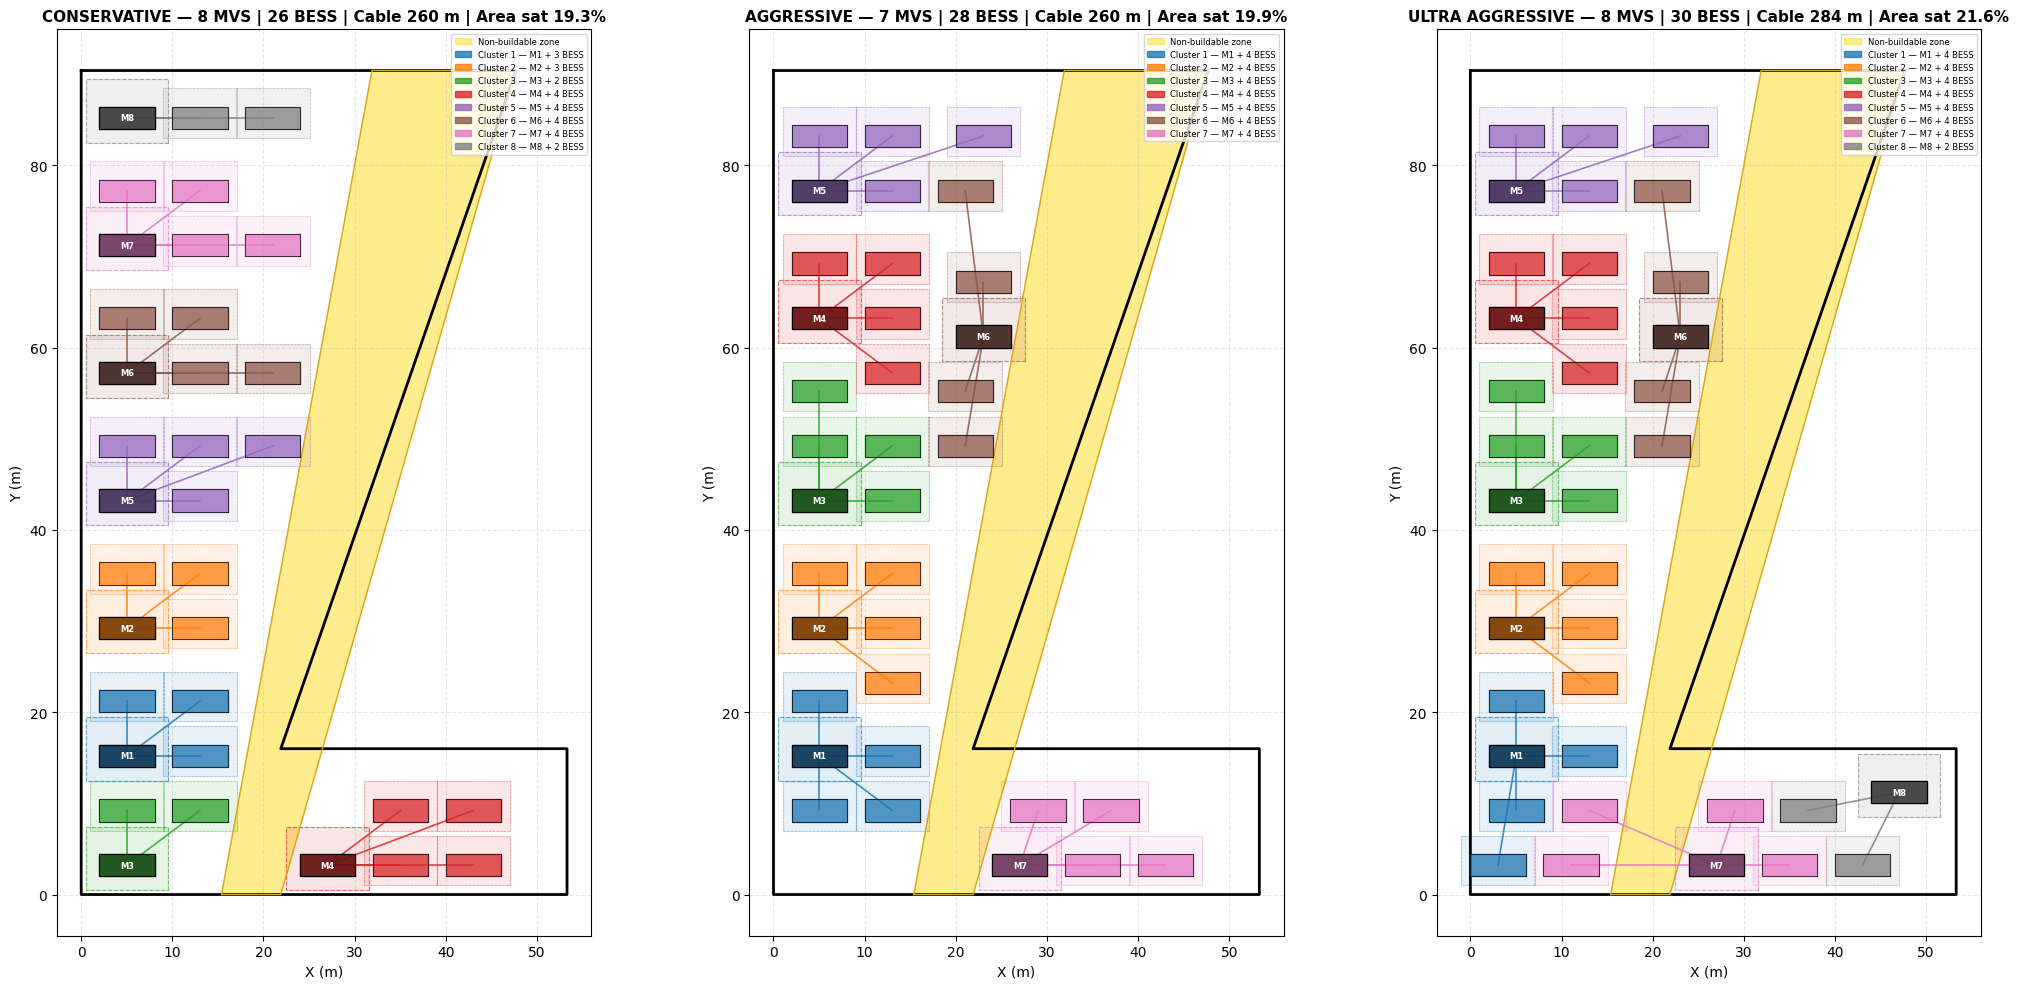

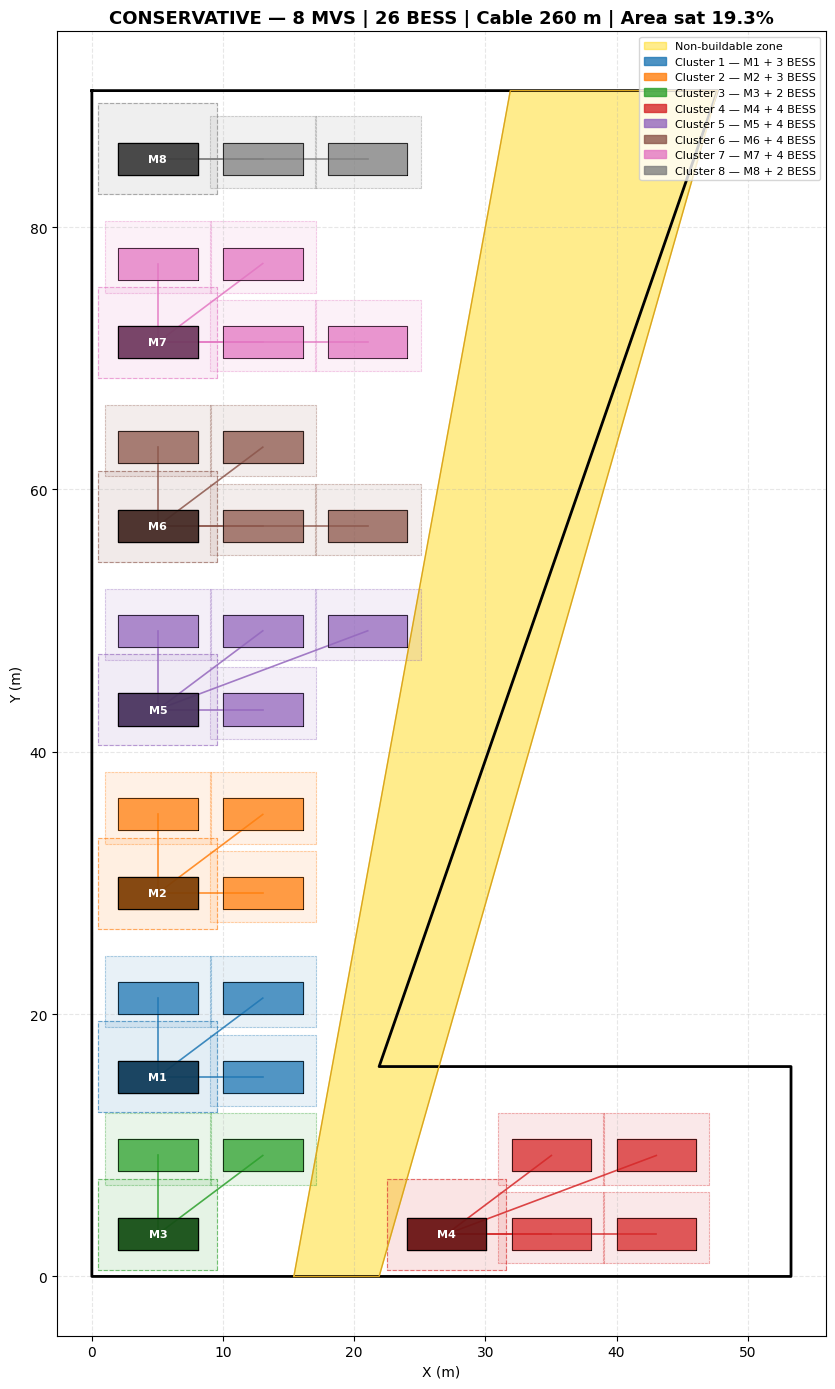

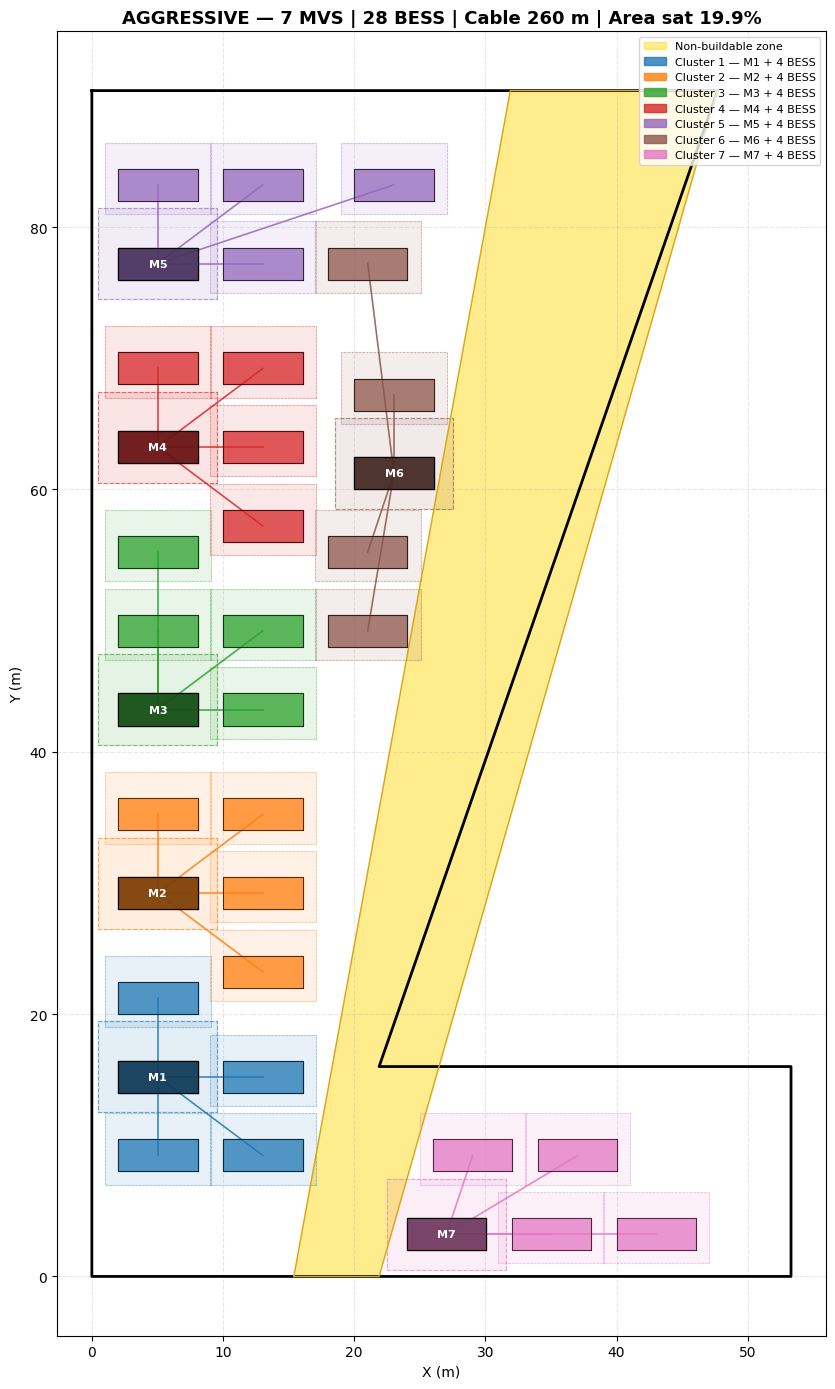

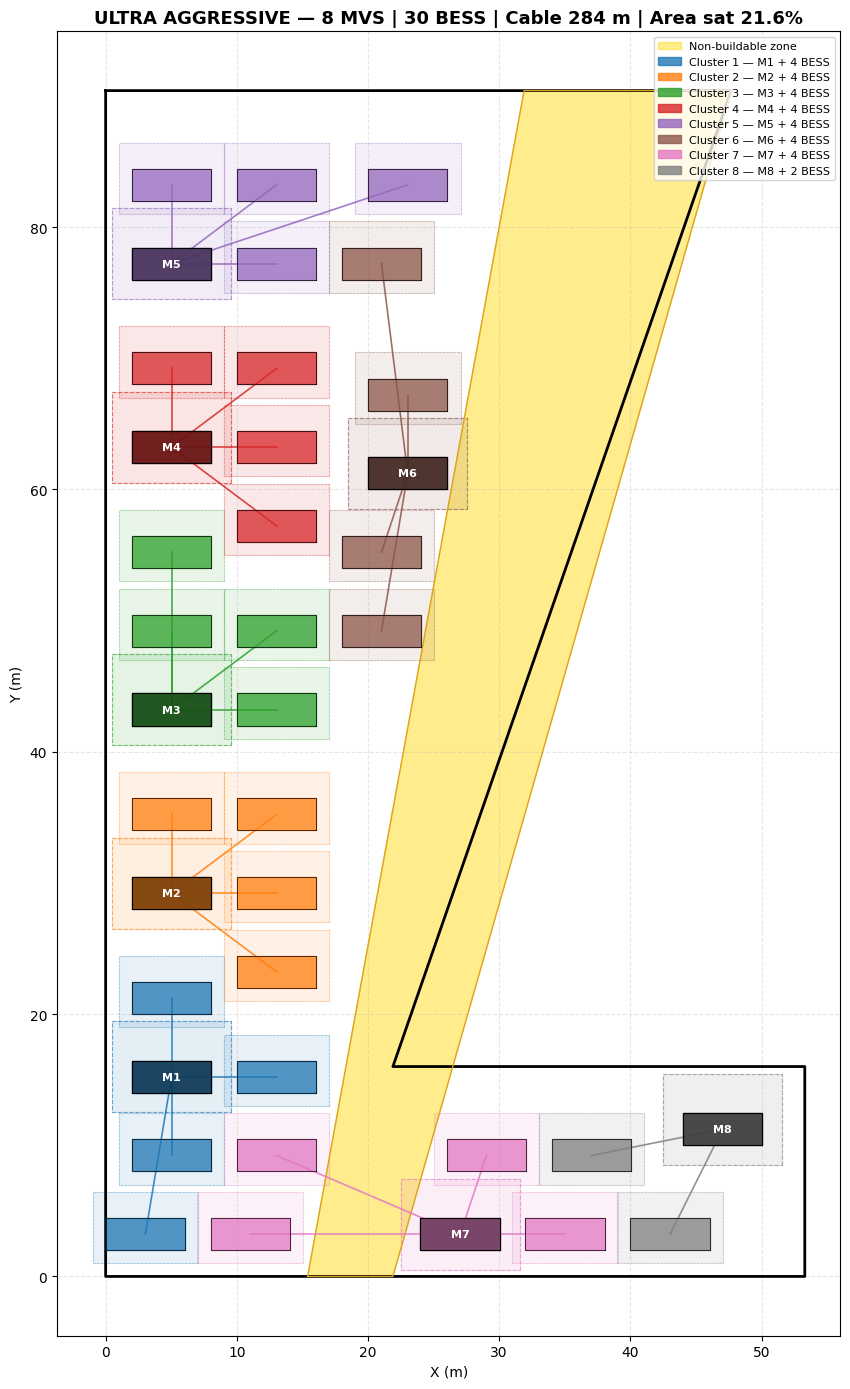

In [12]:
# ════════════════════════════════════════════════════════════════════════
# THREE-MODE COMPARISON
# ════════════════════════════════════════════════════════════════════════
# Runs all three placement profiles against the same CONFIG and reports
# them three ways:
#   1. Side-by-side comparative metrics table (compact, copy/paste-friendly)
#   2. Compact 3-panel overview plot (visual cross-check)
#   3. One full-size standalone figure per scenario (legible detail view)
#
# Mode summary:
#   • CONSERVATIVE     — clean blocks, strict adjacency, 25 m cable cap
#   • AGGRESSIVE       — max BESS under 25 m cap, relaxed adjacency + stragglers
#   • ULTRA-AGGRESSIVE — cable cap lifted everywhere: maximum footprint
#                        saturation, MVS count scales with BESS, Hungarian
#                        rewiring routes over ANY distance (read Max Cable
#                        in the table to see the operating-limit overshoot).
# ════════════════════════════════════════════════════════════════════════

res_conservative     = run_optimization(CONFIG, mode="conservative",     verbose=False)
res_aggressive       = run_optimization(CONFIG, mode="aggressive",       verbose=False)
res_ultra_aggressive = run_optimization(CONFIG, mode="ultra_aggressive", verbose=False)

scenarios = (res_conservative, res_aggressive, res_ultra_aggressive)

# 1. Metrics table
print_comparison(*scenarios)

# 2. Compact 3-panel overview
plot_comparison(*scenarios, config=CONFIG)

# 3. Full-size standalone figures (one per scenario)
plot_all_standalone(*scenarios, config=CONFIG)
